# The Perceptron

The **perceptron** (Rosenblatt, 1958) is a single neuron that learns a linear boundary between two classes. It computes a weighted sum of inputs, applies a sign activation, and updates its weights whenever it misclassifies a point, repeating until every point is correct.

**Net input:** $z = \mathbf{w} \cdot \mathbf{x} + b$

**Activation:** $\hat{y} = \text{sign}(z) \in \{-1, +1\}$

**Update rule:** $w_i \leftarrow w_i + \frac{\eta}{2}(y - \hat{y})x_i,\quad b \leftarrow b + \frac{\eta}{2}(y - \hat{y})$

| Symbol | Meaning |
|--------|---------|
| $\mathbf{x}$ | input vector (one row of training data) |
| $\mathbf{w}$ | learned weight vector (one weight per input) |
| $b$ | bias — shifts the boundary away from the origin |
| $z$ | net input — the raw weighted sum before activation |
| $\hat{y}$ | predicted label (-1 or +1) |
| $y$ | true label |
| $\eta$ | learning rate — controls the size of each weight update |

The Perceptron Convergence Theorem guarantees this converges if the data is linearly separable.

**This notebook** trains on the [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/) dataset, classifying **Adelie** (-1) vs. **Gentoo** (+1) using two measurements: **bill length (mm)** and **bill depth (mm)**. These two species form cleanly separable clusters in that 2D space, making them an ideal test case.

## Imports and Setup

We only need NumPy for the math, pandas to load the data, and matplotlib for plotting. (Seaborn is used purely to make the plots look nicer.)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()  # nicer default plot styling

# Load the Palmer Penguins data from the shared Datasets folder.
# The "../" steps out of this algorithm folder and into Supervised-Learning/Datasets.
#df = pd.read_csv("../Datasets/penguins.csv")

# If you don't have the CSV locally, you can load it straight from seaborn instead:
df = sns.load_dataset("penguins")

# Preview the first 5 rows to confirm the data loaded correctly and see the column names.
df.head()

## The Data

The [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/) dataset records body measurements for 344 penguins of three species, which are *Adelie*, *Chinstrap*, and *Gentoo*, collected near Palmer Station, Antarctica.

A perceptron is a binary classifier, so we need exactly two classes. I'll use **Adelie vs. Gentoo**, because they separate cleanly. And although the dataset has several measurements, the perceptron works with any number of features, so for a clear 2-D picture I'll train on just two: **bill length** and **bill depth** (both in millimeters).

### Preparing the features and labels

Two preprocessing steps:

1. **Filter** down to the two species we care about and drop any rows with missing bill measurements.
2. **Encode the labels.** The sign activation outputs -1 or +1, so we map the species names to those values: Adelie $\rightarrow$ -1, Gentoo $\rightarrow$ +1.

We store the measurements in a matrix `X` (one row per penguin, two columns) and the labels in a vector `y`.

In [51]:
# Adelie occupies rows 0-151, Gentoo rows 220-343 and drop any rows with missing measurements.
two = pd.concat([df.iloc[0:152], df.iloc[220:]]).dropna(
    subset=["bill_length_mm", "bill_depth_mm"]
)

# Encode species as -1 / +1 to match the sign activation
y = np.where(two["species"].values == "Adelie", -1, 1)

# Measurement matrix: bill length and bill depth
X = two[["bill_length_mm", "bill_depth_mm"]].values

print(f"Shape: {X.shape}")
print(f"Adelie (-1): {(y == -1).sum()}  |  Gentoo (+1): {(y == 1).sum()}")

Shape: (274, 2)
Adelie (-1): 151  |  Gentoo (+1): 123


### Are the classes actually separable?

Before training anything, it's worth looking at the data. If the two species form two distinct blobs, a single straight line should be able to separate them, the perceptron should do well.

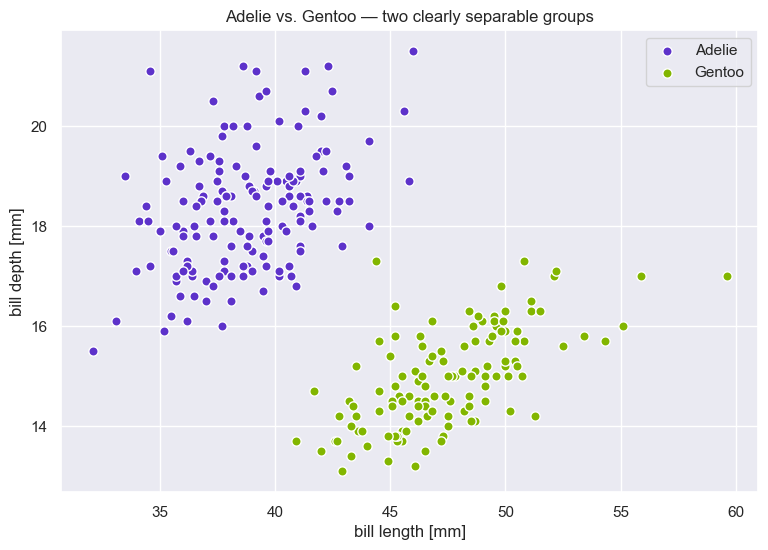

In [49]:
plt.figure(figsize=(9, 6))
for label, name, color in [(-1, "Adelie", "#5d32ca"), (1, "Gentoo", "#82b600")]:
    mask = y == label
    plt.scatter(X[mask, 0], X[mask, 1], label=name, c=color, edgecolors="white", s=45)
plt.xlabel("bill length [mm]")
plt.ylabel("bill depth [mm]")
plt.title("Adelie vs. Gentoo — two clearly separable groups")
plt.legend()
plt.show()

## Implementing the Perceptron from Scratch

### Cost Function

To measure how wrong the model is, we use:

$$C(\mathbf{w}, b) = \frac{1}{4} \sum_{i=1}^{N} (\hat{y}^{(i)} - y^{(i)})^2$$

Because our labels are ±1, the error term $(\hat{y} - y)^2$ can only ever be 0 (correct prediction) or 4 (wrong prediction). The $\frac{1}{4}$ factor cancels that out, so **C equals exactly the number of misclassified points** each epoch. The update rule is derived from minimizing this cost through nudging weights in the direction that reduces it.

### The Class

A Python class is a natural fit for a model: the **attributes** store what the model has learned (the weights, bias, errors, and cost per epoch), and the **methods** are the operations it performs (computing the net input, predicting, and training).

In [52]:
class Perceptron:
    """A single-neuron perceptron classifier for linearly separable, binary data.

    The model learns a weight vector and bias so that sign(w . x + b)
    predicts the class label (+1 or -1).

    Parameters
    ----------
    eta : float
        Learning rate; controls how large each weight update is.
    epochs : int
        Maximum number of passes over the training data.

    Attributes
    ----------
    weights_ : np.ndarray, shape (n_features,)
        Learned feature weights (available after calling train).
    bias_ : float
        Learned bias term.
    errors_ : list of int
        Misclassifications in each epoch, used to visualize convergence.
    costs_ : list of float
        Cost C(w,b) per epoch, equals errors_ since labels are ±1.
    """

    def __init__(self, eta=0.01, epochs=50):
        self.eta = eta
        self.epochs = epochs

    def net_input(self, X):
        """Compute the weighted sum w . x + b (the pre-activation value)."""
        return np.dot(X, self.weights_) + self.bias_

    def predict(self, X):
        """Apply the sign activation: +1 when net input >= 0, else -1."""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

    def train(self, X, y):
        """Learn the weights and bias with the perceptron learning rule."""

        # Start with 2 small random weights (one per measurement) and a zero bias.
        # Small values so the model has no strong opinion before seeing any data.
        self.weights_ = np.random.randn(X.shape[1]) * 0.01
        self.bias_ = 0.0
        self.errors_ = []
        self.costs_ = []

        for _ in range(self.epochs):
            errors = 0

            for xi, target in zip(X, y):
                # Gradient of C(w,b) = (1/4)*sum((y_hat - y)^2) gives a 1/2 factor.
                # update = eta * (1/2) * (y - y_hat), derived from -dC/dw.
                update = self.eta * 0.5 * (target - self.predict(xi))

                # Nudge each weight toward the correct answer.
                # Larger measurements cause larger adjustments.
                self.weights_ += update * xi

                # Bias gets the same correction but isn't tied to any measurement.
                self.bias_ += update

                errors += int(update != 0.0)

            self.errors_.append(errors)

            # C(w,b) = (1/4) * sum((y_hat - y)^2). With ±1 labels this equals the error count.
            self.costs_.append((1/4) * np.sum((self.predict(X) - y) ** 2))

            # All penguins classified correctly — no point running more epochs.
            if errors == 0:
                break

        return self

## Training the Model

We create a `Perceptron`, pick a learning rate and a epoch cap, and call `train`. Because the data is separable, the loop will stop early the moment it reaches zero errors.

In [55]:
clf = Perceptron(eta=0.001, epochs=100)
clf.train(X, y)

print(f"Converged after {len(clf.errors_)} epochs")
print("Learned weights:", clf.weights_)
print("Learned bias:   ", clf.bias_)

Converged after 14 epochs
Learned weights: [ 0.03717664 -0.09215318]
Learned bias:    -0.001


## Evaluating the Predictions

With training done, we compare the model's predictions against the true labels. On linearly separable data a converged perceptron should get **every** point right.

In [56]:
y_hat = clf.predict(X)
accuracy = (y_hat == y).mean()

print(f"Accuracy: {accuracy:.1%}")
print(f"Misclassified penguins: {(y_hat != y).sum()} out of {len(y)}")

Accuracy: 100.0%
Misclassified penguins: 0 out of 274


## Visualizing the Decision Boundary

The most satisfying way to see what the perceptron learned is to color the entire feature plane by what it would predict at each point. The line where the prediction flips from Adelie to Gentoo is the **decision boundary**, which is the straight line the perceptron found.

We do this by evaluating the model on a fine grid of points (a "meshgrid") and shading each region by its predicted class.

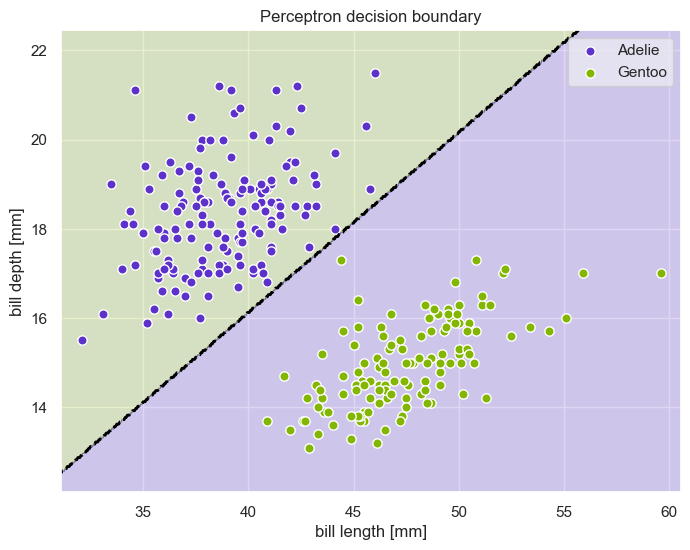

In [57]:
# Build a grid covering the feature space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predict the class for every point on the grid
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid).reshape(xx.shape)

from matplotlib.colors import ListedColormap
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(["#82b600", "#5d32ca"]))   # shaded regions
plt.contour(xx, yy, Z, levels=[0], colors="black", linestyles="dashed", linewidths=2)  # decision boundary
for label, name, color in [(-1, "Adelie", "#5d32ca"), (1, "Gentoo", "#82b600")]:
    mask = y == label
    plt.scatter(X[mask, 0], X[mask, 1], label=name, c=color, edgecolors="white", s=45)
plt.xlabel("bill length [mm]")
plt.ylabel("bill depth [mm]")
plt.title("Perceptron decision boundary")
plt.legend()
plt.show()

## How Fast Did It Learn?

Because we recorded the number of misclassifications each epoch in `errors_`, we can plot the learning process. We expect the error count to fall and then hit **zero**, at which point training stopped. This is the Perceptron Convergence Theorem in action: on linearly separable data, the mistakes are guaranteed to reach zero in a finite number of steps.

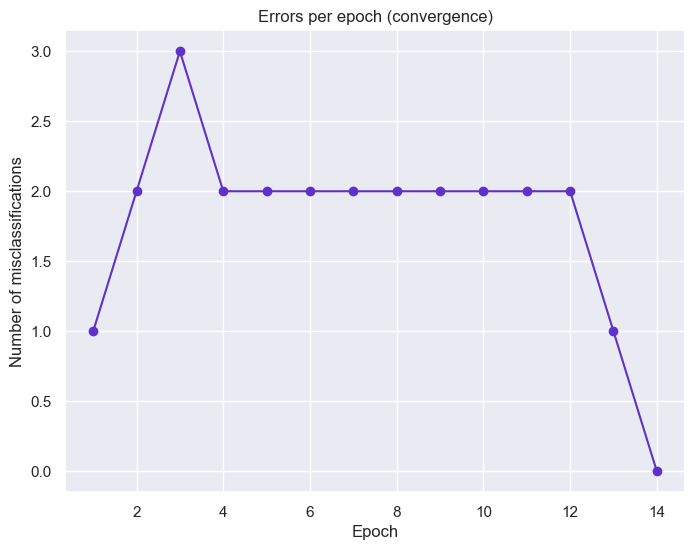

In [60]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(clf.errors_) + 1), clf.errors_, marker="o", color="#5d32ca")
plt.xlabel("Epoch")
plt.ylabel("Number of misclassifications")
plt.title("Errors per epoch (convergence)")
plt.show()

## Conclusion

Our perceptron learned to separate Adelie and Gentoo penguins perfectly, converging in a handful of epochs and drawing a clean straight-line boundary between the two species.

The key reason it worked so well is that the data was **linearly separable**, meaning a single straight line was enough to divide the classes. That is also the perceptron's biggest limitation: when classes overlap and *no* straight line can separate them, the basic perceptron never settles down, since there is always some point on the wrong side.

That limitation is exactly what motivates one of the next models in this repository. **Logistic regression** replaces the hard sign activation with a smooth probability and a loss it can always minimize, so it handles overlapping classes gracefully and even reports how confident it is. We'll see that on a messier, real-world medical dataset next.

In later notebooks, we will split the data into training and test sets to get a fairer measure of performance, which is something that matters more once the problems get harder and the models are no longer perfect.